# Análise Comparativa de Algoritmos Clássicos de Inteligência Artificial na Detecção de Covid-19
## Algoritmo 3: Árvore de Decisão - Pré-processamento de Dados

**Objetivo desta fase:** Consolidar múltiplos ficheiros de séries temporais de frequência cardíaca (formato contínuo) e sinais de alerta (formato JSON) num único *dataset* tabular estruturado. Este *dataset* servirá de entrada para o treino e validação do classificador de Árvore de Decisão.

In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import json
import numpy as np
import os
import glob

# Definição do caminho do diretório de dados
PASTA_DADOS = 'dados'

### 1. Definição da Função de Extração de Características (Feature Engineering)
Nesta etapa, aplicamos o filtro de repouso (`ST_Value == 0`) e extraímos as métricas agregadas diárias, como a Média, o Desvio Padrão e a Variação da Linha de Base (Delta Baseline). Em seguida, os sinais de classificação (0, 1, 2) são mesclados com base na data.

In [2]:
def preparar_dataset_paciente(csv_path, json_path, patient_id):
    """
    Lê e transforma os dados em bruto de um paciente num dataframe tabular.
    """
    # 1. Carregar a série temporal
    df_hr = pd.read_csv(csv_path)
    df_hr['Datetime'] = pd.to_datetime(df_hr['Datetime'])
    df_hr['Data'] = df_hr['Datetime'].dt.date
    
    # 2. Filtrar apenas os períodos de repouso (ST_Value == 0)
    df_repouso = df_hr[df_hr['ST_Value'] == 0].copy()
    
    # 3. Agregação diária de métricas
    df_diario = df_repouso.groupby('Data').agg(
        Media_HR_Repouso=('HR_Value', 'mean'),
        Desvio_Padrao_HR=('HR_Value', 'std'),
        Pico_HR_90pct=('HR_Value', lambda x: np.percentile(x, 90))
    ).reset_index()
    
    df_diario = df_diario.round(2)
    
    # 4. Cálculo da Linha de Base (Média dos primeiros 5 dias)
    baseline_hr = df_diario['Media_HR_Repouso'].head(5).mean()
    df_diario['Delta_Baseline'] = (df_diario['Media_HR_Repouso'] - baseline_hr).round(2)
    df_diario.insert(0, 'ID_Paciente', patient_id)
    
    # 5. Carregar e processar a variável alvo (Sinais)
    with open(json_path, 'r') as f:
        sinais_data = json.load(f)
        
    df_sinais = pd.DataFrame(sinais_data['nightsignal'])
    df_sinais['date'] = pd.to_datetime(df_sinais['date'].str.split('   ').str[0]).dt.date
    df_sinais.rename(columns={'date': 'Data', 'val': 'Status_Alvo'}, inplace=True)
    df_sinais['Status_Alvo'] = pd.to_numeric(df_sinais['Status_Alvo'])
    
    # 6. Unir Features com o Target (Inner Join pela Data)
    dataset_final = pd.merge(df_diario, df_sinais, on='Data', how='inner')
    
    return dataset_final

### 2. Processamento em Lote (Batch Processing)
Iteração sobre todos os ficheiros da pasta `dados/` para processar todos os pacientes e concatenar os resultados num único *DataFrame*.

In [3]:
# Mapear todos os ficheiros de séries temporais na pasta
padrao_busca = os.path.join(PASTA_DADOS, '*_temp.csv')
arquivos_csv = glob.glob(padrao_busca)

lista_datasets = []
print(f"Foram encontrados {len(arquivos_csv)} ficheiros CSV para processamento.")

for csv_path in arquivos_csv:
    # Extrair o ID do paciente do nome do ficheiro (ex: 'P111019')
    nome_ficheiro = os.path.basename(csv_path)
    patient_id = nome_ficheiro.split('_')[0]
    
    # Localizar o JSON correspondente
    json_path = os.path.join(PASTA_DADOS, f"{patient_id}_signals.json")
    
    if os.path.exists(json_path):
        try:
            df_paciente = preparar_dataset_paciente(csv_path, json_path, patient_id)
            lista_datasets.append(df_paciente)
            print(f"[OK] Paciente {patient_id} processado com sucesso.")
        except Exception as e:
            print(f"[ERRO] Falha ao processar o paciente {patient_id}: {e}")
    else:
        print(f"[AVISO] Ficheiro JSON não encontrado para o paciente {patient_id}. Ignorado.")

# Consolidar todos os DataFrames num só
if lista_datasets:
    dataset_completo = pd.concat(lista_datasets, ignore_index=True)
    print(f"\nConsolidação concluída! Total de registos (dias): {len(dataset_completo)}")

Foram encontrados 20 ficheiros CSV para processamento.
[OK] Paciente P111019 processado com sucesso.
[OK] Paciente P182427 processado com sucesso.
[OK] Paciente P230742 processado com sucesso.
[OK] Paciente P261190 processado com sucesso.
[OK] Paciente P271946 processado com sucesso.
[OK] Paciente P277912 processado com sucesso.
[OK] Paciente P305571 processado com sucesso.
[OK] Paciente P308755 processado com sucesso.
[OK] Paciente P319777 processado com sucesso.
[OK] Paciente P333074 processado com sucesso.
[OK] Paciente P389953 processado com sucesso.
[OK] Paciente P430757 processado com sucesso.
[OK] Paciente P442730 processado com sucesso.
[OK] Paciente P469946 processado com sucesso.
[OK] Paciente P476443 processado com sucesso.
[OK] Paciente P476514 processado com sucesso.
[OK] Paciente P500432 processado com sucesso.
[OK] Paciente P530788 processado com sucesso.
[OK] Paciente P543995 processado com sucesso.
[OK] Paciente P584112 processado com sucesso.

Consolidação concluída! 

### 3. Validação e Exportação
Visualização das primeiras linhas do *dataset* consolidado e exportação para o formato CSV, pronto para a modelação com a Árvore de Decisão.

In [4]:
# Exibir amostra dos dados
display(dataset_completo.head())

# Verificar a distribuição das classes do alvo (Normal, Warning, Alert)
print("\nDistribuição das Classes (Status_Alvo):")
print(dataset_completo['Status_Alvo'].value_counts())

# Exportar o ficheiro final
caminho_saida = os.path.join(PASTA_DADOS, 'dataset_consolidado_arvore_decisao.csv')
dataset_completo.to_csv(caminho_saida, index=False)
print(f"\nFicheiro '{caminho_saida}' exportado com sucesso e pronto para o treino!")

,ID_Paciente,Data,Media_HR_Repouso,Desvio_Padrao_HR,Pico_HR_90pct,Delta_Baseline,Status_Alvo
0,P111019,2025-11-28,80.29,14.45,102.0,1.91,0
1,P111019,2025-11-29,77.55,8.25,87.0,-0.83,0
2,P111019,2025-11-30,66.90,8.00,76.0,-11.48,0
3,P111019,2025-12-01,86.29,19.74,109.3,7.91,0
4,P111019,2025-12-02,80.86,11.91,93.0,2.48,0



Distribuição das Classes (Status_Alvo):
Status_Alvo
0    3220
2     365
1     147
Name: count, dtype: int64

Ficheiro 'dados\dataset_consolidado_arvore_decisao.csv' exportado com sucesso e pronto para o treino!


=== Relatório de Classificação ===
              precision    recall  f1-score   support

  Normal (0)       0.96      0.42      0.58       645
 Warning (1)       0.05      0.31      0.08        29
   Alert (2)       0.17      0.64      0.27        73

    accuracy                           0.43       747
   macro avg       0.39      0.46      0.31       747
weighted avg       0.85      0.43      0.53       747



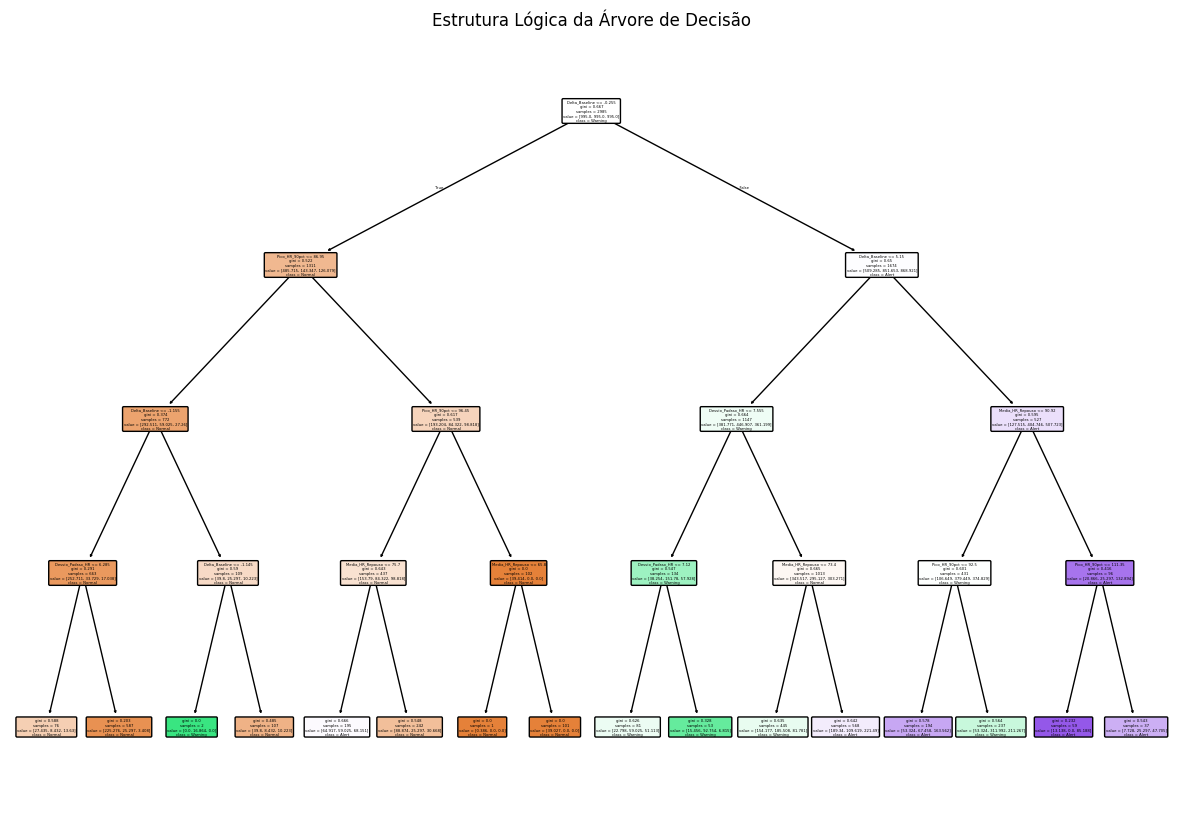

In [1]:
# ==========================================
# FASE DE MODELAÇÃO: ÁRVORE DE DECISÃO
# ==========================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree

# 1. Carregar o dataset estruturado gerado no passo anterior
df = pd.read_csv('dados/dataset_consolidado_arvore_decisao.csv')

# 2. Separar as Variáveis Independentes (Features - X) e a Variável Dependente (Target - y)
# Removemos o ID do paciente e a Data, pois não são variáveis preditivas para o modelo
X = df[['Media_HR_Repouso', 'Desvio_Padrao_HR', 'Pico_HR_90pct', 'Delta_Baseline']]
y = df['Status_Alvo']

# 3. Dividir os dados em conjuntos de Treino e Teste (80% para treino, 20% para teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Inicializar o classificador da Árvore de Decisão
# Adicionando o peso balanceado para dar mais importância às classes minoritárias
classificador_arvore = DecisionTreeClassifier(
    max_depth=4, 
    random_state=42, 
    criterion='gini',
    class_weight='balanced' # <-- A correção acontece aqui
)

# 5. Treinar o modelo com os dados de treino
classificador_arvore.fit(X_train, y_train)

# 6. Fazer previsões com o conjunto de teste
previsoes = classificador_arvore.predict(X_test)

# 7. Avaliar o desempenho do modelo
print("=== Relatório de Classificação ===")
print(classification_report(y_test, previsoes, target_names=['Normal (0)', 'Warning (1)', 'Alert (2)']))

# Opcional: Visualizar a estrutura da árvore gerada
plt.figure(figsize=(15,10))
tree.plot_tree(classificador_arvore, 
               feature_names=X.columns,  
               class_names=['Normal', 'Warning', 'Alert'],
               filled=True, 
               rounded=True)
plt.title("Estrutura Lógica da Árvore de Decisão")
plt.show()

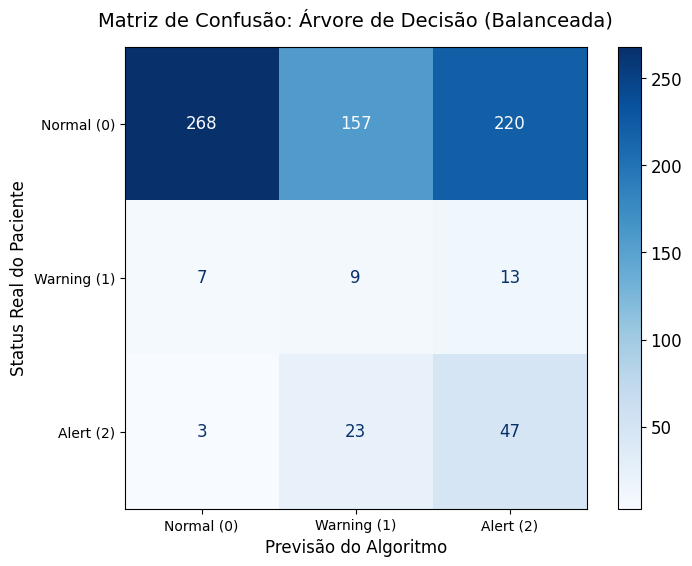

✅ Matriz de confusão exportada com sucesso em alta resolução para: dados/matriz_confusao_arvore.png


In [2]:
# ==========================================
# GERAÇÃO DA MATRIZ DE CONFUSÃO VISUAL
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# 1. Calcular a matriz de confusão bruta
cm = confusion_matrix(y_test, previsoes, labels=classificador_arvore.classes_)

# 2. Configurar o estilo e tamanho da figura
fig, ax = plt.subplots(figsize=(8, 6))
plt.rcParams.update({'font.size': 12}) # Aumenta a fonte para ficar legível nos slides

# 3. Gerar a visualização com as cores (usando o mapa de cores 'Blues')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Normal (0)', 'Warning (1)', 'Alert (2)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

# 4. Adicionar títulos e rótulos
plt.title('Matriz de Confusão: Árvore de Decisão (Balanceada)', fontsize=14, pad=15)
plt.xlabel('Previsão do Algoritmo', fontsize=12)
plt.ylabel('Status Real do Paciente', fontsize=12)

# 5. Salvar a imagem em alta resolução (300 dpi) na pasta dados
caminho_imagem = 'dados/matriz_confusao_arvore.png'
plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')

# Exibir o gráfico na tela do Notebook
plt.show()

print(f"✅ Matriz de confusão exportada com sucesso em alta resolução para: {caminho_imagem}")

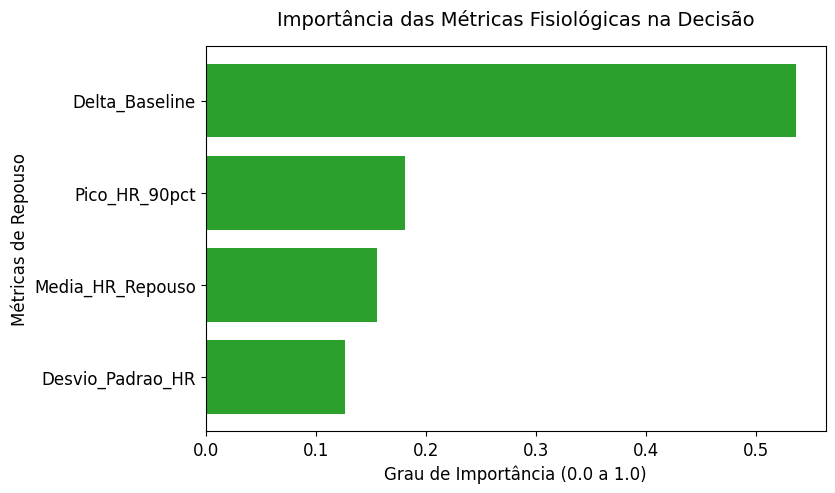

✅ Gráfico de importância exportado com sucesso para: dados/feature_importance_arvore.png


In [3]:
# ==========================================
# IMPORTÂNCIA DAS VARIÁVEIS (FEATURE IMPORTANCE)
# ==========================================

import matplotlib.pyplot as plt
import pandas as pd

# 1. Extrair os valores de importância calculados pela árvore
importancias = classificador_arvore.feature_importances_
nomes_features = X.columns

# 2. Criar uma tabela e ordenar da mais importante para a menos importante
df_imp = pd.DataFrame({'Variavel': nomes_features, 'Importancia': importancias})
df_imp = df_imp.sort_values(by='Importancia', ascending=True)

# 3. Gerar o gráfico de barras horizontais
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_imp['Variavel'], df_imp['Importancia'], color='#2ca02c')

# 4. Adicionar rótulos e estilo
plt.title('Importância das Métricas Fisiológicas na Decisão', fontsize=14, pad=15)
plt.xlabel('Grau de Importância (0.0 a 1.0)', fontsize=12)
plt.ylabel('Métricas de Repouso', fontsize=12)

# 5. Salvar a imagem em alta resolução
caminho_imp = 'dados/feature_importance_arvore.png'
plt.savefig(caminho_imp, dpi=300, bbox_inches='tight')

plt.show()
print(f"✅ Gráfico de importância exportado com sucesso para: {caminho_imp}")